In [1]:
import numpy as np


In [2]:
import numpy as np
rng = np.random.default_rng(2026)

N = 100
H_N = sum(1/i for i in range(1, N+1))
baseline_teorico = (N / 7) * H_N

resultados = {}

for k in [1, 2, 5, 10]:
    sobres_por_simulacion = []

    for _ in range(10_000):
        album = [0] * 100
        repetidas = 0
        completas = 0
        sobres = 0
        faltantes = list(range(100))

        while completas < 100:
            for _ in range(7):
                numero = rng.integers(0, 100)
                if album[numero] == 0:
                    album[numero] = 1
                    completas += 1
                    faltantes.remove(numero)
                else:
                    repetidas += 1

            while repetidas >= k and faltantes:
                repetidas -= k
                elegida = rng.choice(faltantes)
                album[elegida] = 1
                completas += 1
                faltantes.remove(elegida)

            sobres += 1

        sobres_por_simulacion.append(sobres)

    media = np.mean(sobres_por_simulacion)
    std   = np.std(sobres_por_simulacion)
    reduccion = (baseline_teorico - media) / baseline_teorico * 100

    resultados[k] = (media, std, reduccion, sobres_por_simulacion)

print(f"Baseline teórico (sin intercambio): {baseline_teorico:.2f} sobres\n")
print(f"{'K':<5} {'Media':<12} {'Std':<12} {'Reducción %':<12}")
print("-" * 41)
for k, (media, std, reduccion, sobres_por_simulacion) in resultados.items():
    print(f"{k:<5} {media:<12.2f} {std:<12.2f} {reduccion:<12.2f}%")

Baseline teórico (sin intercambio): 74.11 sobres

K     Media        Std          Reducción % 
-----------------------------------------
1     15.00        0.00         79.76       %
2     20.02        0.55         72.99       %
5     28.52        1.46         61.51       %
10    35.87        2.44         51.60       %


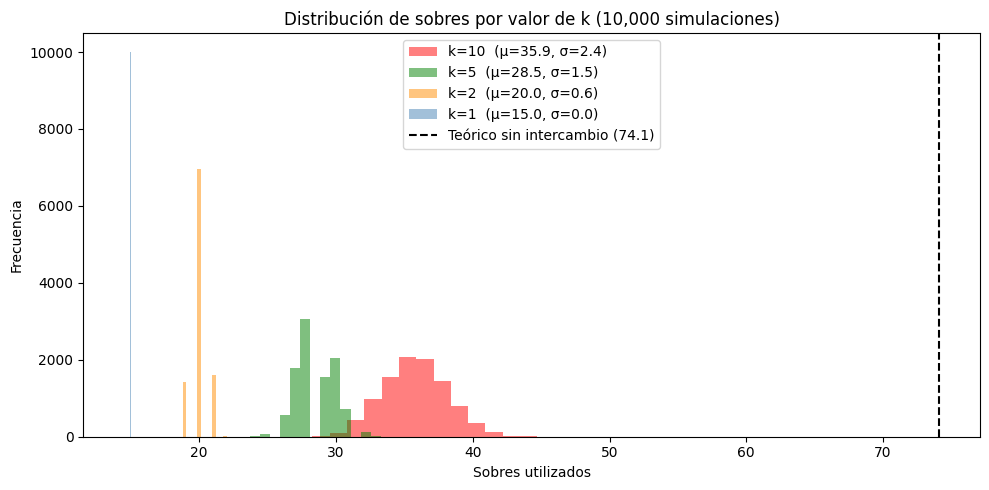

In [3]:
import matplotlib.pyplot as plt

colores = {1: 'steelblue', 2: 'darkorange', 5: 'green', 10: 'red'}

plt.figure(figsize=(10, 5))

for k in [10, 5, 2, 1]:  
    media, std, _, datos, = resultados[k]
    plt.hist(datos, bins=15, alpha=0.5, color=colores[k],
             label=f'k={k}  (μ={media:.1f}, σ={std:.1f})')

plt.axvline(baseline_teorico, color='black', linestyle='--', linewidth=1.5,
            label=f'Teórico sin intercambio ({baseline_teorico:.1f})')
plt.xlabel('Sobres utilizados')
plt.ylabel('Frecuencia')
plt.title('Distribución de sobres por valor de k (10,000 simulaciones)')
plt.legend()
plt.tight_layout()
plt.show()

# Parte B

In [4]:
import numpy as np

rng = np.random.default_rng(2026)

M_valores = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
K_valores = [1, 2, 5, 10]



resultados_prob = {k: {} for k in K_valores}

for k in K_valores:
    for m in M_valores:
        exitos = 0

        for _ in range(10000):
            album = [0] * 100
            repetidas = 0
            completas = 0
            faltantes = list(range(100))

            for _ in range(m):
                for _ in range(7):
                    numero = rng.integers(0, 100)
                    if album[numero] == 0:
                        album[numero] = 1
                        completas += 1
                        faltantes.remove(numero)
                    else:
                        repetidas += 1

                while repetidas >= k and faltantes:  
                    repetidas -= k
                    elegida = rng.choice(faltantes)
                    album[elegida] = 1
                    completas += 1
                    faltantes.remove(elegida)

            if completas == 100:
                exitos += 1

        resultados_prob[k][m] = exitos / 10000


header = f"{'M':<6}" + "".join(f"{'k='+str(k):<10}" for k in K_valores)
print(header)
print("-" * len(header))
for m in M_valores:
    fila = f"{m:<6}" + "".join(f"{resultados_prob[k][m]:<10.3f}" for k in K_valores)
    print(fila)

M     k=1       k=2       k=5       k=10      
----------------------------------------------
20    1.000     0.834     0.000     0.000     
25    1.000     1.000     0.009     0.000     
30    1.000     1.000     0.907     0.014     
35    1.000     1.000     1.000     0.514     
40    1.000     1.000     1.000     0.983     
45    1.000     1.000     1.000     1.000     
50    1.000     1.000     1.000     1.000     
55    1.000     1.000     1.000     1.000     
60    1.000     1.000     1.000     1.000     
65    1.000     1.000     1.000     1.000     
70    1.000     1.000     1.000     1.000     


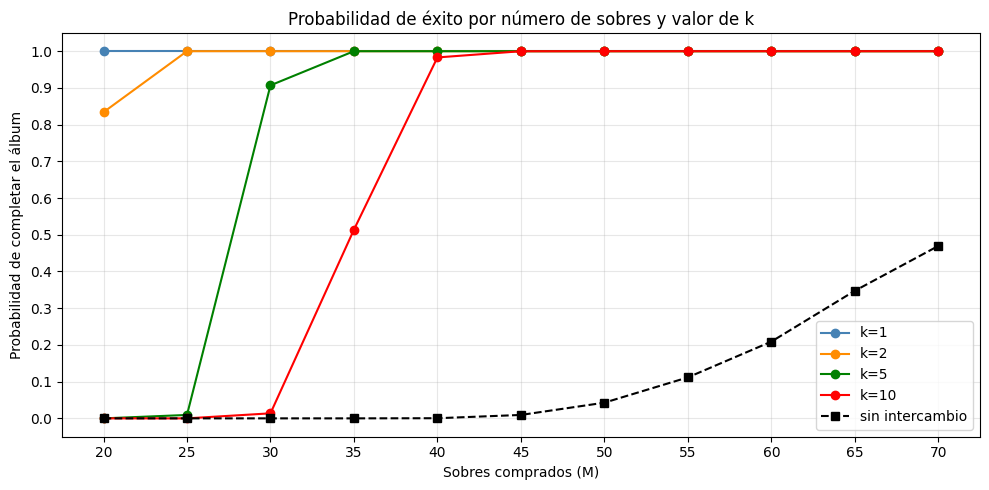

In [5]:
# Curva de referencia: sin intercambio
prob_sin_intercambio = {}
for m in M_valores:
    exitos = 0
    for _ in range(10000):
        album = [0] * 100
        completas = 0
        for _ in range(m):
            for _ in range(7):
                numero = rng.integers(0, 100)
                if album[numero] == 0:
                    album[numero] = 1
                    completas += 1
        if completas == 100:
            exitos += 1
    prob_sin_intercambio[m] = exitos / 10000

# Grafica
colores = {1: 'steelblue', 2: 'darkorange', 5: 'green', 10: 'red'}

plt.figure(figsize=(10, 5))

for k in K_valores:
    probs = [resultados_prob[k][m] for m in M_valores]
    plt.plot(M_valores, probs, marker='o', color=colores[k], label=f'k={k}')

probs_ref = [prob_sin_intercambio[m] for m in M_valores]
plt.plot(M_valores, probs_ref, marker='s', color='black', linestyle='--', label='sin intercambio')

plt.xlabel('Sobres comprados (M)')
plt.ylabel('Probabilidad de completar el álbum')
plt.title('Probabilidad de éxito por número de sobres y valor de k')
plt.xticks(M_valores)
plt.yticks([i/10 for i in range(11)])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
umbrales = [0.50, 0.75, 0.90]

header = f"{'K':<6}{'P=50%':<12}{'P=75%':<12}{'P=90%':<12}"
print(header)
print("-" * len(header))

for k in K_valores:
    probs = [resultados_prob[k][m] for m in M_valores]
    fila = f"{k:<6}"
    for p in umbrales:
        m_interp = np.interp(p, probs, M_valores)
        fila += f"{m_interp:<12.1f}"
    print(fila)

# Sin intercambio
probs_ref = [prob_sin_intercambio[m] for m in M_valores]
fila = f"{'ref':<6}"
for p in umbrales:
    m_interp = np.interp(p, probs_ref, M_valores)
    fila += f"{m_interp:<12.1f}"
print(fila)

K     P=50%       P=75%       P=90%       
------------------------------------------
1     20.0        20.0        20.0        
2     20.0        20.0        22.0        
5     27.7        29.1        30.0        
10    34.9        37.5        39.1        
ref   70.0        70.0        70.0        
